# 05 · Descriptivos del subcorpus COM-B
**Proyecto:** Marco COM-B en la esfera pública — análisis de tweets en español
**Equivalente original:** `6_descriptivos_ciencia.ipynb` + `6_1_nubes_palabras_comparativas.ipynb`

Analiza el subcorpus de tweets que expresan algún componente del COM-B:
volumen, evolución temporal, autores, tipos de cuenta, subcomponentes,
nubes de palabras y tablas de frecuencias.

**Entradas:**
- `resultadosCOMB/comb_tweets_final.parquet`
- `resultadosCOMB/corpus_cleaned.parquet`

**Salidas:** figuras `fig_*.png`, `tabla_frecuencias_comb.xlsx`, `tabla_reducida_frecuencias.xlsx`


## 0 · Configuración

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB')

COL_AUTOR   = 'Author_Normalized'
COL_ENTIDAD = 'Entidad'
COL_FECHA   = 'Fecha'

print('[CONFIG] OK')
print(f'  DATA_PROCESSED : {DATA_PROCESSED.resolve()}')


[CONFIG] OK
  DATA_PROCESSED : C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB


## 1 · Imports y carga de datos

In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# Equivalente a: ciencia_chunks.xlsx + corpus_cleaned.xlsx + chunks.parquet
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import spacy, re, subprocess, sys
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('crest')

# Subcorpus de componentes del COM-B + corpus completo
tweets_comp  = pd.read_parquet(DATA_PROCESSED / 'comb_tweets_final.parquet')
corpus       = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')

corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

# Merge metadatos al subcorpus del COM-B
cols_meta = ['id_doc', 'Author_Normalized', 'Entidad', 'Fecha',
             'Texto_limpio', 'Sentimiento', 'Polaridad']
cols_meta = [c for c in cols_meta if c in corpus.columns]

tweets_comp  = tweets_comp.merge(corpus[cols_meta], on='id_doc', how='left')
tweets_comp['Fecha']  = pd.to_datetime(tweets_comp['Fecha'], errors='coerce')
tweets_comp['Anio']  = tweets_comp['Fecha'].dt.year
tweets_comp['Mes']   = tweets_comp['Fecha'].dt.month

print(f'Corpus completo    : {len(corpus):,} tweets')
print(f'Subcorpus comp.    : {len(tweets_comp):,} tweets '
      f'({len(tweets_comp)/len(corpus)*100:.1f}%)')
tweets_comp.head(3)


Corpus completo    : 151,424 tweets
Subcorpus comp.    : 12,254 tweets (8.1%)


,chunk_id,id_doc,texto_chunk,COMB_Capacidad_fisica,COMB_Capacidad_psicologica,COMB_Motivacion_automatica,COMB_Motivacion_reflexiva,COMB_Oportunidad_fisica,COMB_Oportunidad_social,score_max,...,etiqueta_comb,categoria_detectada,Author_Normalized,Entidad,Fecha,Texto_limpio,Sentimiento,Polaridad,Anio,Mes
0,5_1,5,Local Gestionan regidores cajas para intubació...,0.374892,0.315076,0.261424,0.284109,0.510342,0.272318,0.510342,...,1,COMB_Oportunidad_fisica,@cscnoticias1,"Noticias locales, nacionales o globales",2020-06-03,Local Gestionan regidores cajas para intubació...,otro,Neutra,2020,6
1,6_1,6,La otra semana ya saldrá el aumento de contagi...,0.281226,0.367581,0.299257,0.363866,0.482989,0.208974,0.482989,...,1,COMB_Oportunidad_fisica,@bebita11385037,Autoridad local de salud o gobierno,2020-06-03,La otra semana ya saldrá el aumento de contagi...,otro,Neutra,2020,6
2,12_1,12,"Ayuda para TOSAGUAMANAB, el contagio del Covid...",0.321023,0.439551,0.447290,0.440611,0.518141,0.287017,0.518141,...,1,COMB_Oportunidad_fisica,@jeancarpal23,Literatura científica,2020-06-03,"Ayuda para TOSAGUAMANAB, el contagio del Covid...",tristeza,Negativa,2020,6


## 2 · Estadísticos básicos
Equivalente a las celdas 10–13 del paper.

In [3]:
# ============================================================
# CELL 2 — ESTADISTICOS BASICOS
# Equivalente a celdas 10-13 del paper
# ============================================================

n_total      = len(corpus)
n_comp       = len(tweets_comp)
n_docs_total = corpus['id_doc'].nunique()
n_docs_comp  = tweets_comp['id_doc'].nunique()

print('=' * 55)
print('ESTADISTICOS DEL SUBCORPUS DE COM-B')
print('=' * 55)
print(f'  Total tweets en corpus         : {n_total:,}')
print(f'  Tweets con COM-B     : {n_comp:,}')
# Equivalente a: (7267/62651)*100
print(f'  % tweets comp. / total         : {n_comp/n_total*100:.2f}%')
print(f'  Autores distintos (comp.)      : {tweets_comp[COL_AUTOR].nunique():,}')
print(f'  Autores distintos (corpus)     : {corpus[COL_AUTOR].nunique():,}')
# Equivalente a: (4154/13676)*100
print(f'  % autores con comp. / total    : '
      f'{tweets_comp[COL_AUTOR].nunique()/corpus[COL_AUTOR].nunique()*100:.2f}%')
print(f'  Rango de fechas                : '
      f'{tweets_comp[COL_FECHA].min().date()} -> {tweets_comp[COL_FECHA].max().date()}')
print('=' * 55)


ESTADISTICOS DEL SUBCORPUS DE COM-B
  Total tweets en corpus         : 151,424
  Tweets con COM-B     : 12,254
  % tweets comp. / total         : 8.09%
  Autores distintos (comp.)      : 10,098
  Autores distintos (corpus)     : 79,938
  % autores con comp. / total    : 12.63%
  Rango de fechas                : 2020-03-31 -> 2020-08-18


## 3 · Distribución de tweets del COM-B por autor
Equivalente a las celdas 14–18 del paper:  
cuántos fragmentos de ciencia tiene cada columna → cuántos tweets del COM-B tiene cada autor.

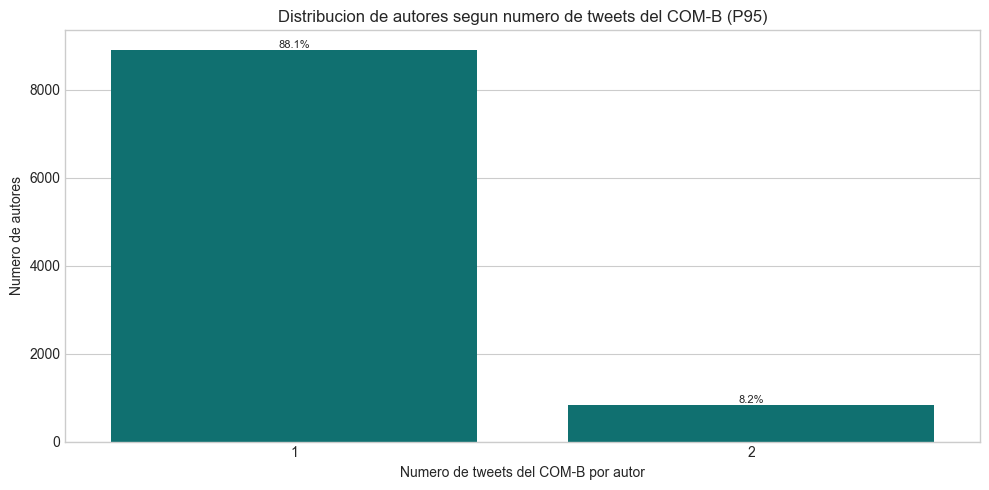

       num_autores  porcentaje
count                         
1             8900       88.14
2              825        8.17
3              185        1.83
4               76        0.75
5               46        0.46
6               24        0.24
7               12        0.12
8                9        0.09
9                4        0.04
10               3        0.03


In [4]:
# ============================================================
# CELL 3 — TWEETS DE COMP. POR AUTOR
# Equivalente a celdas 14-15 del paper
# ============================================================

# Cuantos tweets del COM-B tiene cada autor (equiv. cuántos chunks de ciencia por columna)
conteo_por_autor = tweets_comp[COL_AUTOR].value_counts().reset_index()
conteo_por_autor.columns = [COL_AUTOR, 'num_tweets_comp']

# Distribucion: cuantos autores tienen 1, 2, 3... tweets del COM-B (equiv. cell 15)
distribucion = tweets_comp[COL_AUTOR].value_counts().value_counts().sort_index()
porcentajes_dist = distribucion / distribucion.sum() * 100

# Solo mostrar hasta el percentil 95 para que el grafico sea legible
p95 = int(np.percentile(conteo_por_autor['num_tweets_comp'], 95))
dist_plot = distribucion[distribucion.index <= p95]
pct_plot  = porcentajes_dist[porcentajes_dist.index <= p95]

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=dist_plot.index, y=dist_plot.values, color='teal')
for i, (x, y) in enumerate(zip(dist_plot.index, dist_plot.values)):
    ax.text(i, y + 0.5, f'{pct_plot.iloc[i]:.1f}%', ha='center', va='bottom', fontsize=8)
plt.title('Distribucion de autores segun numero de tweets del COM-B (P95)')
plt.xlabel('Numero de tweets del COM-B por autor')
plt.ylabel('Numero de autores')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_dist_tweets_comp_por_autor.png', dpi=300)
plt.show()

print(distribucion.head(10).to_frame('num_autores').assign(porcentaje=porcentajes_dist.head(10).round(2)))


In [5]:
# ============================================================
# CELL 4 — PROPORCION COMP / TOTAL POR AUTOR
# Equivalente a celdas 16-18 del paper (proporcion ciencia/chunks por columna)
# ============================================================

tweets_por_autor_total = corpus[COL_AUTOR].value_counts().reset_index()
tweets_por_autor_total.columns = [COL_AUTOR, 'num_tweets_total']

df_ratio = conteo_por_autor.merge(tweets_por_autor_total, on=COL_AUTOR, how='left')
df_ratio['proporcion_comp'] = df_ratio['num_tweets_comp'] / df_ratio['num_tweets_total']

print('Estadisticos de proporcion del COM-B por autor:')
print(df_ratio['proporcion_comp'].describe().round(4))

promedio_tweets_total  = df_ratio['num_tweets_total'].mean()
promedio_tweets_comp   = df_ratio['num_tweets_comp'].mean()
promedio_prop_comp     = df_ratio['proporcion_comp'].mean()

print(f'\nPromedio de tweets totales por autor  : {promedio_tweets_total:.2f}')
print(f'Promedio de tweets del COM-B por autor  : {promedio_tweets_comp:.2f}')
print(f'Promedio de proporcion del COM-B        : {promedio_prop_comp*100:.2f}%')


Estadisticos de proporcion del COM-B por autor:
count    10098.0000
mean         0.7075
std          0.3489
min          0.0118
25%          0.3333
50%          1.0000
75%          1.0000
max          1.0000
Name: proporcion_comp, dtype: float64

Promedio de tweets totales por autor  : 3.90
Promedio de tweets del COM-B por autor  : 1.21
Promedio de proporcion del COM-B        : 70.75%


## 4 · Distribución temporal
Equivalente a las celdas 20–21 del paper.

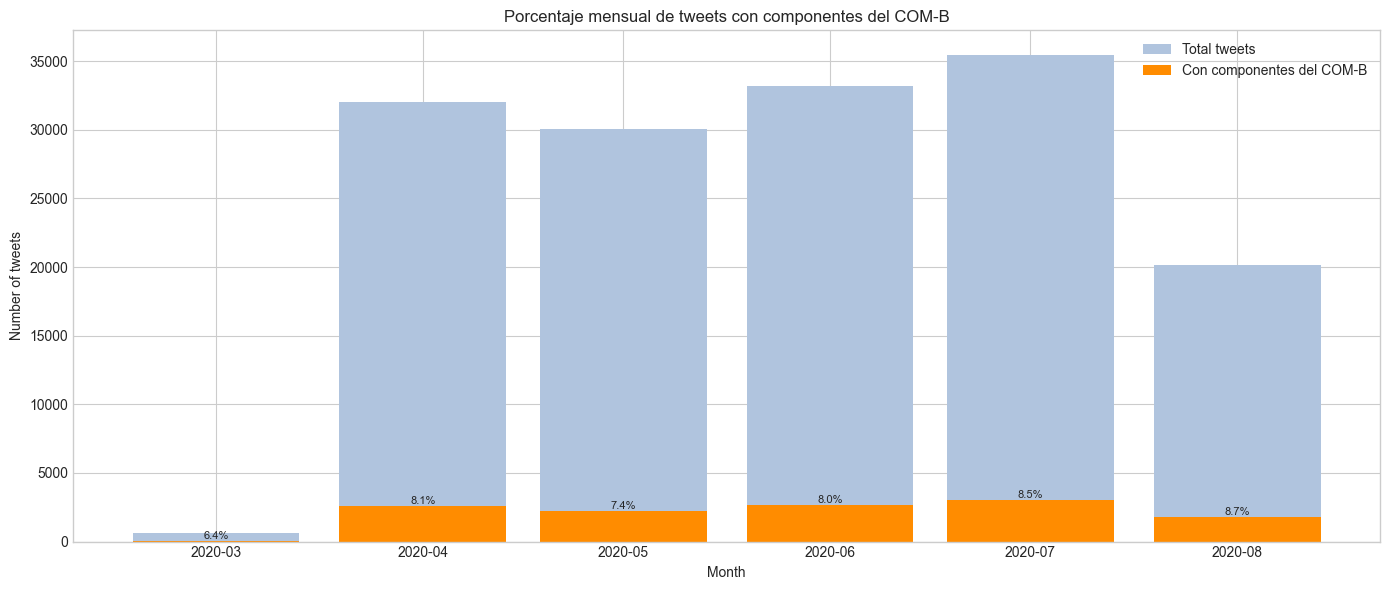

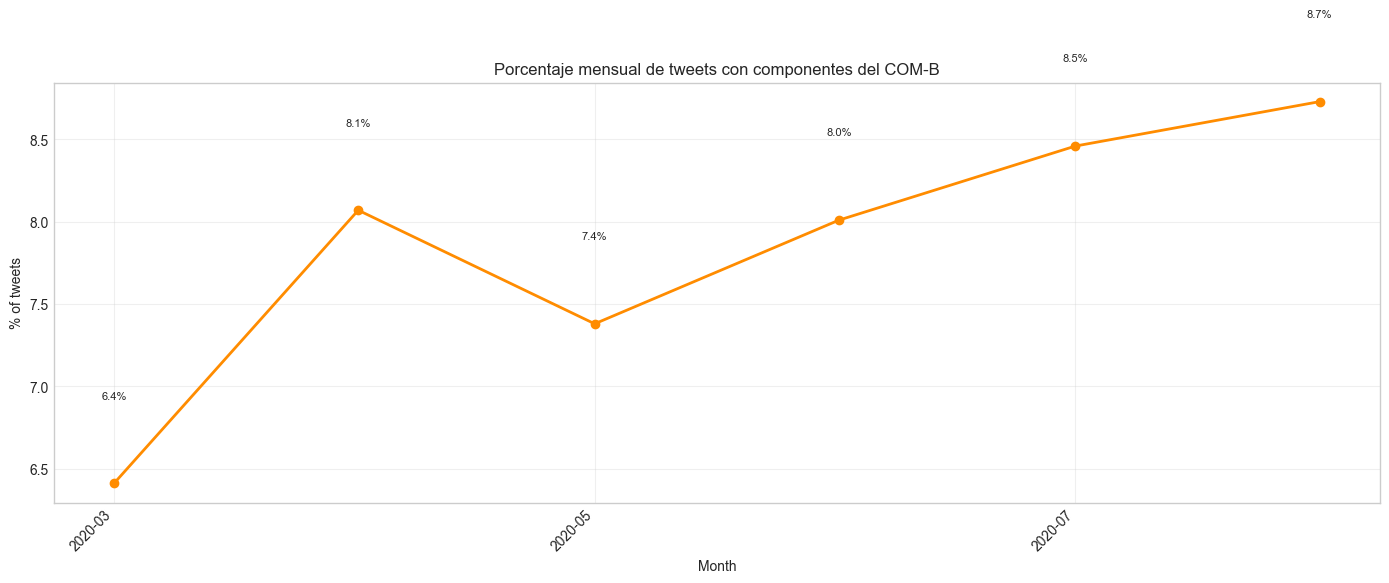

,total_tweets,tweets_comp,porcentaje
AnoMes,,,
2020-03-01,593,38,6.41
2020-04-01,32000,2581,8.07
2020-05-01,30048,2218,7.38
2020-06-01,33193,2659,8.01
2020-07-01,35469,3001,8.46
2020-08-01,20121,1757,8.73


In [6]:
# ============================================================
# CELL 5 — DISTRIBUCION TEMPORAL
# Equivalente a celdas 20-21 del paper
# ============================================================

corpus['AnoMes']       = corpus[COL_FECHA].dt.to_period('M')
tweets_comp['AnoMes']  = tweets_comp[COL_FECHA].dt.to_period('M')

totales   = corpus.groupby('AnoMes')['id_doc'].nunique()
con_comp  = tweets_comp.groupby('AnoMes')['id_doc'].nunique()

mensual = pd.DataFrame({'total_tweets': totales, 'tweets_comp': con_comp}).fillna(0)
mensual['porcentaje'] = (mensual['tweets_comp'] / mensual['total_tweets'] * 100).round(2)
mensual.index = mensual.index.to_timestamp()

# Grafica 1: barras apiladas
plt.figure(figsize=(14, 6))
plt.bar(mensual.index, mensual['total_tweets'],
        color='lightsteelblue', label='Total tweets', width=25)
plt.bar(mensual.index, mensual['tweets_comp'],
        color='darkorange', label='Con componentes del COM-B', width=25)
for x, y_s, pct in zip(mensual.index, mensual['tweets_comp'], mensual['porcentaje']):
    if y_s > 0:
        plt.text(x, y_s + 2, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
plt.title('Porcentaje mensual de tweets con componentes del COM-B')
plt.ylabel('Number of tweets')
plt.xlabel('Month')
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_comportamiento_barras.png', dpi=300)
plt.show()

# Grafica 2: linea de porcentaje
plt.figure(figsize=(14, 6))
plt.plot(mensual.index, mensual['porcentaje'], marker='o', linestyle='-', color='darkorange', linewidth=2)
for x, y in zip(mensual.index, mensual['porcentaje']):
    if not np.isnan(y):
        plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=8)
plt.title('Porcentaje mensual de tweets con componentes del COM-B')
plt.ylabel('% of tweets')
plt.xlabel('Month')
plt.grid(alpha=0.3)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_comportamiento_linea.png', dpi=300)
plt.show()
mensual.tail(10)


## 5 · Autores con más tweets del COM-B
Equivalente a las celdas 22–25 del paper.

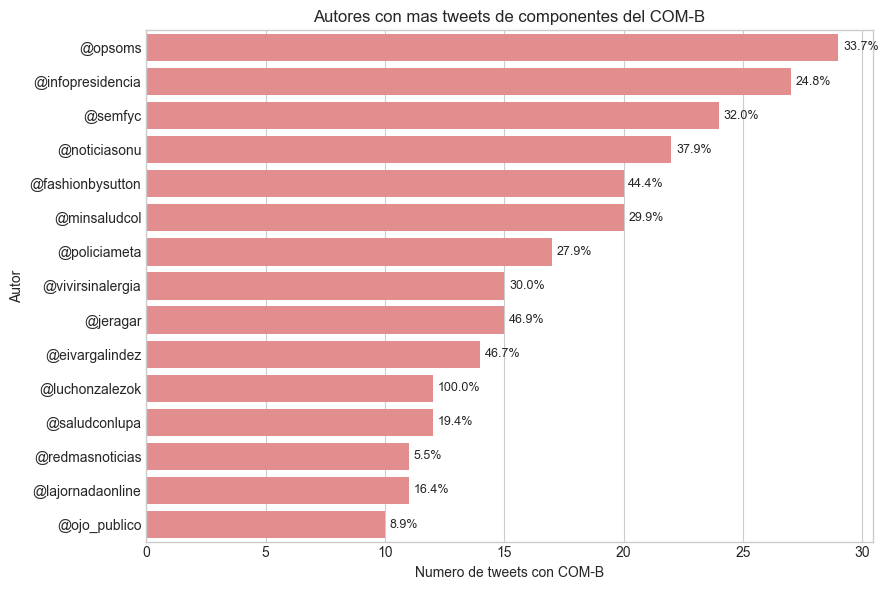

In [7]:
# ============================================================
# CELL 6 — TOP AUTORES (gráfico simple, equiv. cell 23)
# ============================================================

autores_comp  = (tweets_comp.groupby(COL_AUTOR)['id_doc'].nunique()
    .sort_values(ascending=False).reset_index(name='n_tweets_comp'))
autores_total = (corpus.groupby(COL_AUTOR)['id_doc'].nunique()
    .reset_index(name='total_columnas'))
autores_merge = autores_comp.merge(autores_total, on=COL_AUTOR, how='left')
autores_merge['porcentaje_comp'] = (
    autores_merge['n_tweets_comp'] / autores_merge['total_columnas'] * 100).round(2)

top_autores = autores_merge.head(15)

plt.figure(figsize=(9, 6))
orden = top_autores.sort_values('n_tweets_comp', ascending=False)[COL_AUTOR]
sns.barplot(data=top_autores, y=COL_AUTOR, x='n_tweets_comp', order=orden, color='lightcoral')
for i, (n, p) in enumerate(zip(top_autores['n_tweets_comp'], top_autores['porcentaje_comp'])):
    plt.text(n + 0.2, i, f'{p:.1f}%', va='center', fontsize=9)
plt.title('Autores con mas tweets de componentes del COM-B')
plt.xlabel('Numero de tweets con COM-B')
plt.ylabel('Autor')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_comportamiento_simple.png', dpi=300)
plt.show()


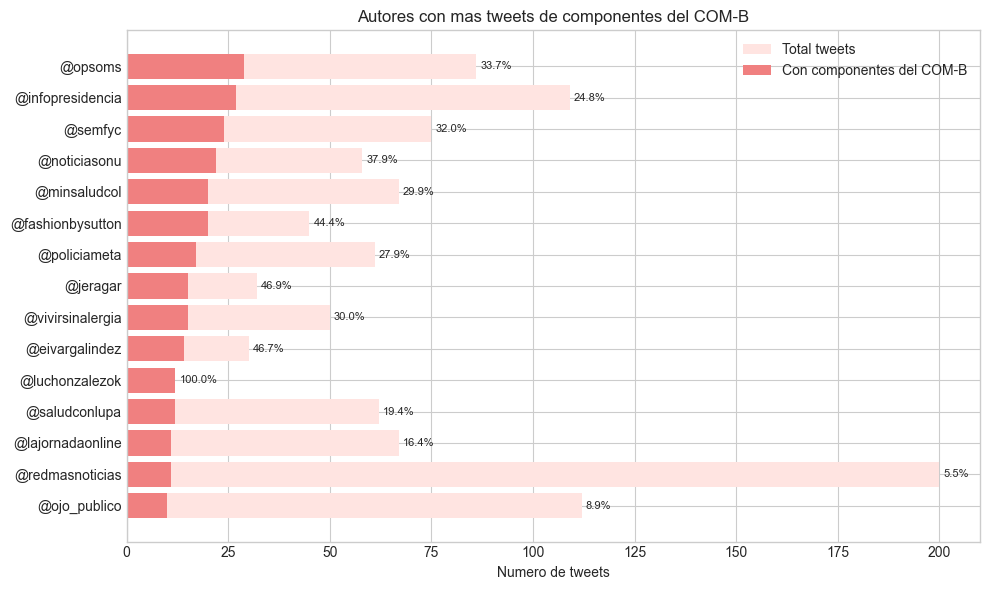

,Author_Normalized,n_tweets_comp,total_columnas,porcentaje_comp
0,@opsoms,29,86,33.72
1,@infopresidencia,27,109,24.77
2,@semfyc,24,75,32.00
3,@noticiasonu,22,58,37.93
4,@fashionbysutton,20,45,44.44
5,@minsaludcol,20,67,29.85
6,@policiameta,17,61,27.87
7,@vivirsinalergia,15,50,30.00
8,@jeragar,15,32,46.88
9,@eivargalindez,14,30,46.67


In [8]:
# ============================================================
# CELL 7 — TOP AUTORES (gráfico comparativo total vs salud, equiv. cell 24)
# ============================================================

top_sorted = top_autores.sort_values('n_tweets_comp', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_sorted[COL_AUTOR], top_sorted['total_columnas'],
         color='mistyrose', label='Total tweets')
plt.barh(top_sorted[COL_AUTOR], top_sorted['n_tweets_comp'],
         color='lightcoral', label='Con componentes del COM-B')
for i, (n, t, p) in enumerate(zip(
    top_sorted['n_tweets_comp'], top_sorted['total_columnas'], top_sorted['porcentaje_comp']
)):
    plt.text(t + 1, i, f'{p:.1f}%', va='center', fontsize=8)
plt.title('Autores con mas tweets de componentes del COM-B')
plt.xlabel('Numero de tweets')
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_comportamiento_comparativo.png', dpi=300)
plt.show()
top_autores


## 6 · Por subcategorías
Equivalente a las celdas 26–31 del paper.

TABLA DE SUBCATEGORIAS DE COM-B
Total tweets del COM-B: 12,254
------------------------------------------------------------
              Subcategoria  N_tweets  Porcentaje
   COMB_Oportunidad_fisica      6009       49.04
 COMB_Motivacion_reflexiva      3031       24.73
COMB_Capacidad_psicologica      1696       13.84
COMB_Motivacion_automatica       822        6.71
   COMB_Oportunidad_social       461        3.76
     COMB_Capacidad_fisica       235        1.92


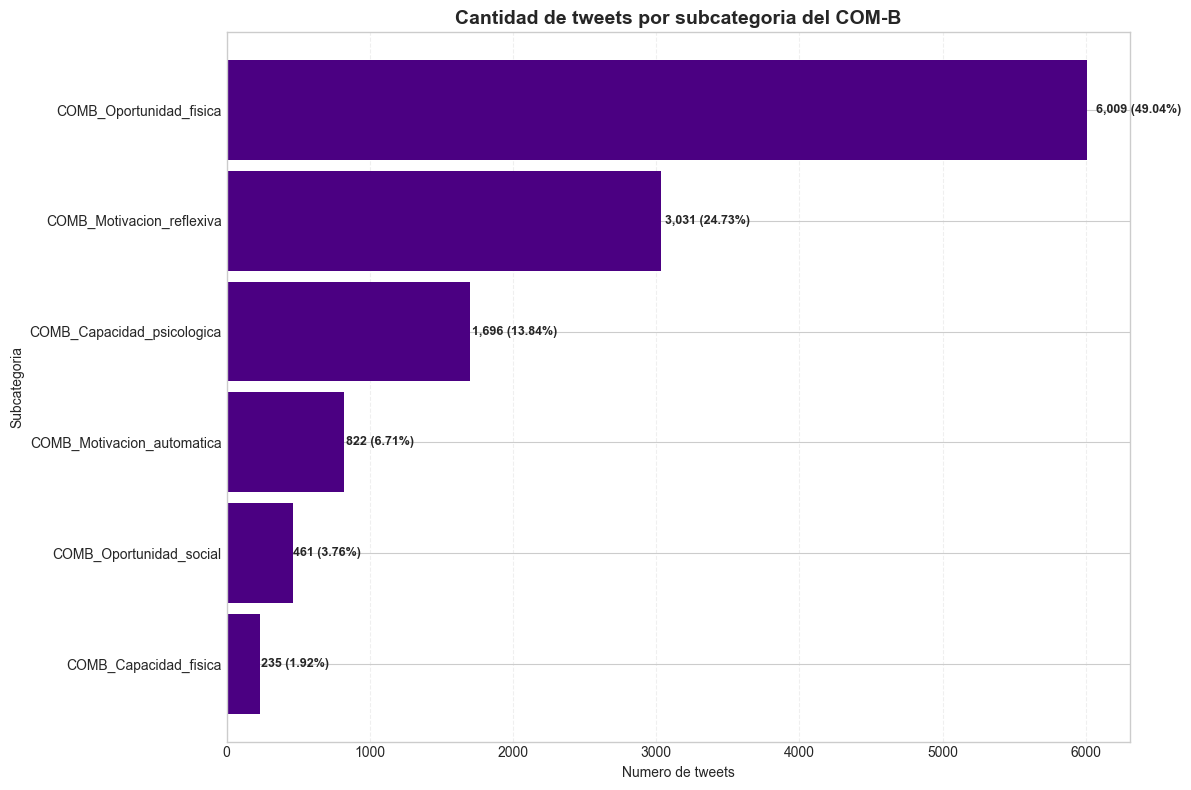

[GUARDADO] subcategorias_tweets.csv


In [9]:
# ============================================================
# CELL 8 — SUBCATEGORIAS: barplot + tabla + CSV (equiv. cells 28-30)
# ============================================================

subcats_cols = [c for c in tweets_comp.columns if c.startswith('COMB_')]
tweets_comp['subcategoria_max']  = tweets_comp[subcats_cols].idxmax(axis=1)

conteos     = tweets_comp['subcategoria_max'].value_counts()
total_s     = conteos.sum()
porcentajes = (conteos / total_s * 100).round(2)

tabla_subcats = pd.DataFrame({
    'Subcategoria': conteos.index,
    'N_tweets'    : conteos.values,
    'Porcentaje'  : porcentajes.values,
}).sort_values('N_tweets', ascending=False)

print('=' * 60)
print('TABLA DE SUBCATEGORIAS DE COM-B')
print('=' * 60)
print(f'Total tweets del COM-B: {total_s:,}')
print('-' * 60)
print(tabla_subcats.to_string(index=False))

# Grafico
conteos_ord = conteos.sort_values(ascending=True)
plt.figure(figsize=(12, 8))
ax = conteos_ord.plot.barh(color='indigo', width=0.9)
for i, (v, pct) in enumerate(zip(
    conteos_ord.values, porcentajes[conteos_ord.index].values
)):
    ax.text(v + v*0.01, i, f'{v:,} ({pct}%)', va='center', fontsize=9, fontweight='bold')
plt.title('Cantidad de tweets por subcategoria del COM-B', fontsize=14, fontweight='bold')
plt.xlabel('Numero de tweets')
plt.ylabel('Subcategoria')
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_subcategorias_tweets.png', dpi=300)
plt.show()

# Guardar CSV (equiv. Karen: subcategorias_cientificas.csv)
tabla_subcats.to_csv(DATA_PROCESSED / 'subcategorias_tweets.csv', index=False, encoding='utf-8-sig')
print('[GUARDADO] subcategorias_tweets.csv')


Autores distintos por subcategoria:
subcategoria_max
COMB_Oportunidad_fisica       5172
COMB_Motivacion_reflexiva     2705
COMB_Capacidad_psicologica    1579
COMB_Motivacion_automatica     767
COMB_Oportunidad_social        445
COMB_Capacidad_fisica          224


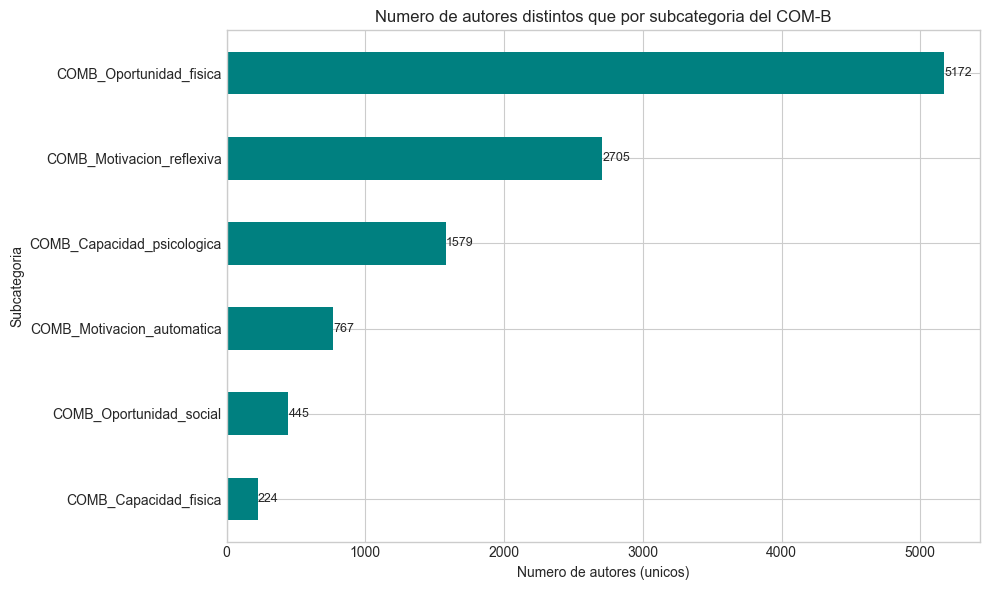

In [10]:
# ============================================================
# CELL 9 — AUTORES POR SUBCATEGORIA (equiv. cell 31)
# ============================================================

autores_por_subcat = (
    tweets_comp.groupby('subcategoria_max')[COL_AUTOR]
    .nunique().sort_values(ascending=False)
)

print('Autores distintos por subcategoria:')
print(autores_por_subcat.to_string())

plt.figure(figsize=(10, 6))
ax = autores_por_subcat.sort_values().plot.barh(color='teal')
for i, v in enumerate(autores_por_subcat.sort_values().values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.title('Numero de autores distintos que por subcategoria del COM-B')
plt.xlabel('Numero de autores (unicos)')
plt.ylabel('Subcategoria')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_por_subcategoria.png', dpi=300)
plt.show()


## 7 · Distribución por tipo de cuenta
Equivalente adicional — reemplaza distribución por diario.

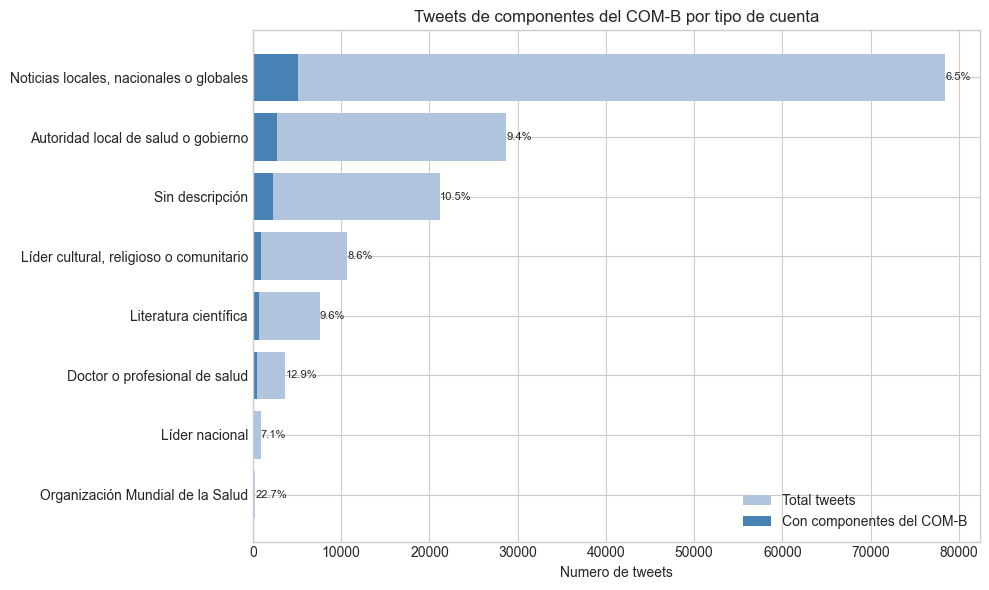

,Entidad,n_comp,n_total,pct_comp
5,"Noticias locales, nacionales o globales",5096,78475,6.5
0,Autoridad local de salud o gobierno,2703,28684,9.4
7,Sin descripción,2215,21195,10.5
3,"Líder cultural, religioso o comunitario",922,10705,8.6
2,Literatura científica,723,7554,9.6
1,Doctor o profesional de salud,474,3677,12.9
4,Líder nacional,62,874,7.1
6,Organización Mundial de la Salud,59,260,22.7


In [11]:
# ============================================================
# CELL 10 — POR TIPO DE CUENTA (Entidad)
# ============================================================

entidad_comp  = tweets_comp.groupby(COL_ENTIDAD)['id_doc'].nunique().reset_index(name='n_comp')
entidad_total = corpus.groupby(COL_ENTIDAD)['id_doc'].nunique().reset_index(name='n_total')
entidad_merge = entidad_comp.merge(entidad_total, on=COL_ENTIDAD, how='left')
entidad_merge['pct_comp']  = (entidad_merge['n_comp'] / entidad_merge['n_total'] * 100).round(1)
entidad_merge = entidad_merge.sort_values('n_comp', ascending=False)

top_ent = entidad_merge.sort_values('n_comp', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top_ent[COL_ENTIDAD], top_ent['n_total'], color='lightsteelblue', label='Total tweets')
plt.barh(top_ent[COL_ENTIDAD], top_ent['n_comp'], color='steelblue', label='Con componentes del COM-B')
for i, (n, t, p) in enumerate(zip(top_ent['n_comp'], top_ent['n_total'], top_ent['pct_comp'])):
    plt.text(t + 1, i, f'{p:.1f}%', va='center', fontsize=8)
plt.title('Tweets de componentes del COM-B por tipo de cuenta')
plt.xlabel('Numero de tweets')
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_entidad_comp.png', dpi=300)
plt.show()
entidad_merge


## 8 · Nubes de palabras
Equivalente a las celdas 32–34 del paper + `6_1_nubes_palabras_comparativas.ipynb`.

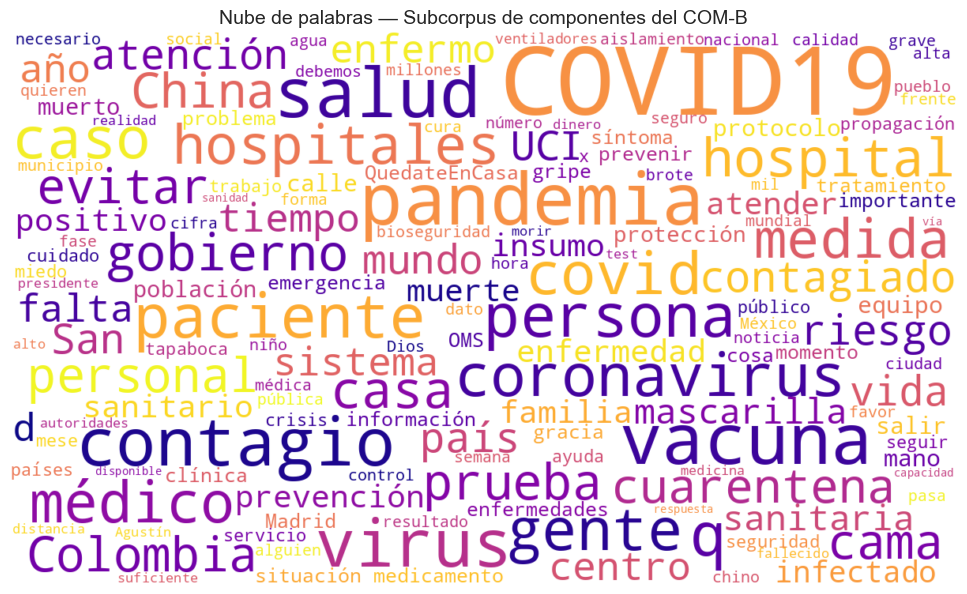

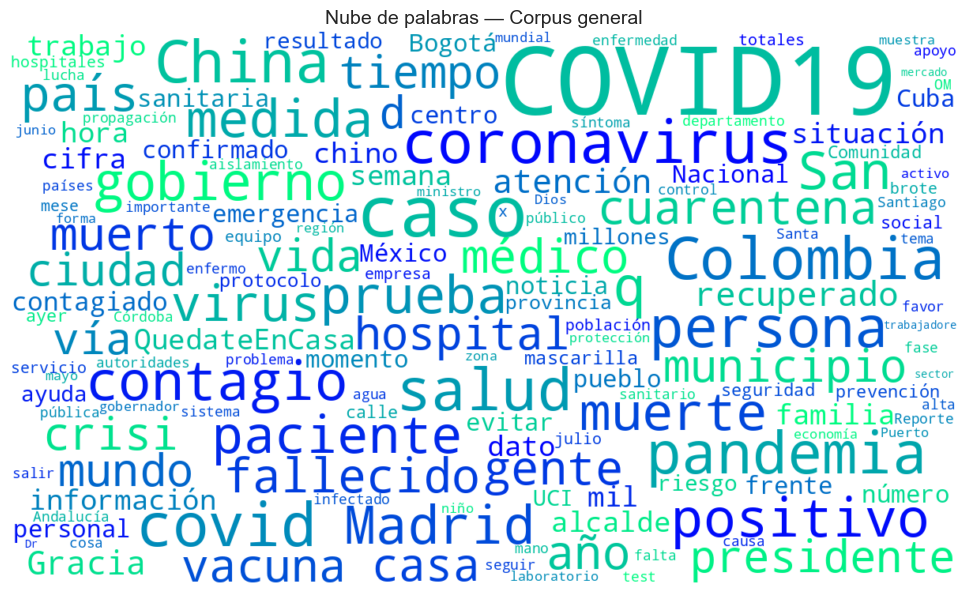

[GUARDADO] nube_subcorpus_comp.png  +  nube_corpus_general.png


In [12]:
# ============================================================
# CELL 11 — NUBES DE PALABRAS
# Equivalente a celdas 33-34 del paper
# ============================================================

subprocess.run([sys.executable, '-m', 'spacy', 'download', 'es_core_news_sm'], capture_output=True)
nlp = spacy.load('es_core_news_sm')
STOP_WORDS = nlp.Defaults.stop_words

WC_PARAMS = dict(
    width=1200, height=700, background_color='white',
    stopwords=STOP_WORDS, max_words=150,
    collocations=False, prefer_horizontal=1.0,
    relative_scaling=0.3, max_font_size=120, min_font_size=8,
    random_state=42,
)

# Nube 1: subcorpus del COM-B (equiv. nube de fragmentos de ciencia)
texto_comp  = ' '.join(tweets_comp['Texto_limpio'].dropna())
wc_comp  = WordCloud(**WC_PARAMS, colormap='plasma').generate(texto_comp)
plt.figure(figsize=(10, 6))
plt.imshow(wc_comp, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Subcorpus de componentes del COM-B', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_subcorpus_comp.png', dpi=300)
plt.show()

# Nube 2: corpus general (adicional comparativo)
texto_general = ' '.join(corpus['Texto_limpio'].dropna())
wc_general = WordCloud(**WC_PARAMS, colormap='winter').generate(texto_general)
plt.figure(figsize=(10, 6))
plt.imshow(wc_general, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Corpus general', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_corpus_general.png', dpi=300)
plt.show()
print('[GUARDADO] nube_subcorpus_comp.png  +  nube_corpus_general.png')


## 9 · Tablas de palabras más frecuentes
Equivalente a las celdas 35–37 del paper.

In [13]:
# ============================================================
# CELL 12 — FUNCION obtener_frecuencias
# Replica exacta de utils.obtener_frecuencias() del paper
# ============================================================

from tqdm import tqdm

def obtener_frecuencias(textos, stopwords, n=None, lematizar=False):
    """Replica de utils.obtener_frecuencias() del paper."""
    texto_unido = ' '.join(map(str, textos)).lower()
    tokens = re.findall(r'\b[a-záéíóúüñ]+\b', texto_unido)  # mismo regex que Karen
    tokens = [t for t in tokens if t not in stopwords and len(t) > 2]

    if not lematizar:
        return Counter(tokens).most_common(n)

    print('Lematizando textos...')
    lemas = []
    for doc in tqdm(nlp.pipe(tokens, batch_size=500, disable=['ner','parser'], n_process=2),
                    total=len(tokens), desc='Lematizando'):
        lemas.extend([t.lemma_.lower() for t in doc if t.is_alpha and len(t) > 2])
    return Counter([l for l in lemas if l not in stopwords]).most_common(n)


In [14]:
# ============================================================
# CELL 13 — FRECUENCIAS SIN LEMATIZAR (equiv. cell 37)
# corpus + comp + cuentas_con_comp
# ============================================================

autores_con_comp  = tweets_comp[COL_AUTOR].unique()
textos_cuentas_comp  = corpus[corpus[COL_AUTOR].isin(autores_con_comp)]['Texto_limpio']

df_corpus_freq = pd.DataFrame(
    obtener_frecuencias(corpus['Texto_limpio'], STOP_WORDS, n=None),
    columns=['palabra', 'frecuencia_corpus']
)
df_comp_freq = pd.DataFrame(
    obtener_frecuencias(tweets_comp['Texto_limpio'], STOP_WORDS, n=None),
    columns=['palabra', 'frecuencia_comp']
)
df_cuentas_freq = pd.DataFrame(
    obtener_frecuencias(textos_cuentas_comp, STOP_WORDS, n=None),
    columns=['palabra', 'frecuencia_cuentas']
)

tabla_frecuencias = (
    df_corpus_freq
    .merge(df_comp_freq, on='palabra', how='outer')
    .merge(df_cuentas_freq, on='palabra', how='outer')
    .fillna(0)
)
tabla_frecuencias[['frecuencia_corpus','frecuencia_comp','frecuencia_cuentas']] = (
    tabla_frecuencias[['frecuencia_corpus','frecuencia_comp','frecuencia_cuentas']].astype(int)
)
tabla_frecuencias['proporcion_comp'] = tabla_frecuencias.apply(
    lambda r: r['frecuencia_comp'] / r['frecuencia_corpus'] if r['frecuencia_corpus'] > 0 else 0, axis=1
)
tabla_frecuencias['proporcion_cuentas'] = tabla_frecuencias.apply(
    lambda r: r['frecuencia_cuentas'] / r['frecuencia_corpus'] if r['frecuencia_corpus'] > 0 else 0, axis=1
)

tabla_top = tabla_frecuencias.sort_values('frecuencia_comp', ascending=False).head(30)
tabla_top.head(20)


,palabra,frecuencia_corpus,frecuencia_comp,frecuencia_cuentas,proporcion_comp,proporcion_cuentas
87320,pandemia,10253,2054,4145,0.200332,0.404272
106511,salud,10454,1745,4070,0.166922,0.389325
121497,vacuna,3550,1568,2013,0.441690,0.567042
123962,virus,5596,1503,2321,0.268585,0.414761
29462,coronavirus,10907,1049,3545,0.096177,0.325021
30223,covid,11314,1017,1804,0.089889,0.159448
55187,gente,4553,992,1462,0.217878,0.321107
86712,pacientes,5143,978,2298,0.190161,0.446821
90427,personas,7876,926,2715,0.117572,0.344718
28046,contagio,3422,872,1548,0.254822,0.452367


## 10 · Tabla reducida para el artículo
Equivalente a la celda 38 del paper (Karen guarda LaTeX; aquí guardamos Excel).

In [15]:
# ============================================================
# CELL 14 — TABLA REDUCIDA PARA EL ARTICULO (equiv. cell 38)
# Karen: LaTeX (.tex)  →  aqui: Excel (.xlsx)
# ============================================================

tabla_reducida = tabla_top[['palabra','frecuencia_corpus','frecuencia_cuentas','proporcion_cuentas']].copy()
tabla_reducida['proporcion_cuentas'] = tabla_reducida['proporcion_cuentas'].round(2)
tabla_reducida = tabla_reducida.rename(columns={
    'palabra'           : 'Palabra',
    'frecuencia_corpus' : 'Freq. corpus',
    'frecuencia_cuentas': 'Freq. cuentas con COM-B',
    'proporcion_cuentas': 'Proporcion cuentas',
})

ruta_reducida = DATA_PROCESSED / 'tabla_reducida_frecuencias.xlsx'
tabla_reducida.to_excel(ruta_reducida, index=False, engine='openpyxl')
print(f'[GUARDADO] tabla_reducida_frecuencias.xlsx')
tabla_reducida


[GUARDADO] tabla_reducida_frecuencias.xlsx


,Palabra,Freq. corpus,Freq. cuentas con COM-B,Proporcion cuentas
87320,pandemia,10253,4145,0.40
106511,salud,10454,4070,0.39
121497,vacuna,3550,2013,0.57
123962,virus,5596,2321,0.41
29462,coronavirus,10907,3545,0.33
30223,covid,11314,1804,0.16
55187,gente,4553,1462,0.32
86712,pacientes,5143,2298,0.45
90427,personas,7876,2715,0.34
28046,contagio,3422,1548,0.45


## 11 · Frecuencias lematizadas *(opcional)*
Equivalente a las celdas 39–44 del paper.

> **Antes de correr:** elige una opción:
> - `LEMATIZAR = False` + `CARGAR = True` → carga desde parquet si ya existen
> - `LEMATIZAR = True`  + `CARGAR = False` → recalcula (puede tardar varios minutos)


In [16]:
# ============================================================
# CELL 15 — FRECUENCIAS LEMATIZADAS (equiv. cells 41-42)
# ============================================================

LEMATIZAR = False   # True para recalcular
CARGAR    = True    # True para cargar desde parquet si existe

ruta_corpus_lem = DATA_PROCESSED / 'frecuencias_corpus_lematizado.parquet'
ruta_comp_lem   = DATA_PROCESSED / 'frecuencias_comb_lematizado.parquet'

if CARGAR and ruta_corpus_lem.exists() and ruta_comp_lem.exists():
    df_corpus_lem = pd.read_parquet(ruta_corpus_lem)
    df_comp_lem   = pd.read_parquet(ruta_comp_lem)
    print('Frecuencias lematizadas cargadas desde parquet')
elif LEMATIZAR:
    df_corpus_lem = pd.DataFrame(
        obtener_frecuencias(corpus['Texto_limpio'], STOP_WORDS, n=None, lematizar=True),
        columns=['palabra', 'frecuencia_corpus']
    )
    df_comp_lem = pd.DataFrame(
        obtener_frecuencias(tweets_comp['Texto_limpio'], STOP_WORDS, n=None, lematizar=True),
        columns=['palabra', 'frecuencia_comp']
    )
    print('Frecuencias lematizadas calculadas')
else:
    print('Skipped: establece LEMATIZAR=True o CARGAR=True')
    df_corpus_lem = df_corpus_freq.rename(columns={'frecuencia_corpus':'frecuencia_corpus'})
    df_comp_lem   = df_comp_freq.rename(columns={'frecuencia_comp':'frecuencia_comp'})


Skipped: establece LEMATIZAR=True o CARGAR=True


In [17]:
# ============================================================
# CELL 16 — MERGE LEMATIZADO (equiv. cell 43)
# ============================================================

tabla_lem = (
    df_corpus_lem.merge(df_comp_lem, on='palabra', how='outer').fillna(0)
)
for col in ['frecuencia_corpus','frecuencia_comp']:
    if col in tabla_lem.columns:
        tabla_lem[col] = tabla_lem[col].astype(int)

if 'frecuencia_corpus' in tabla_lem and 'frecuencia_comp' in tabla_lem:
    tabla_lem['proporcion_comp'] = tabla_lem.apply(
        lambda r: r['frecuencia_comp'] / r['frecuencia_corpus'] if r['frecuencia_corpus'] > 0 else 0,
        axis=1
    )

tabla_lem_top = tabla_lem.sort_values('frecuencia_comp', ascending=False)
tabla_lem_top.head(10)


,palabra,frecuencia_corpus,frecuencia_comp,proporcion_comp
87320,pandemia,10253,2054,0.200332
106511,salud,10454,1745,0.166922
121497,vacuna,3550,1568,0.441690
123962,virus,5596,1503,0.268585
29462,coronavirus,10907,1049,0.096177
30223,covid,11314,1017,0.089889
55187,gente,4553,992,0.217878
86712,pacientes,5143,978,0.190161
90427,personas,7876,926,0.117572
28046,contagio,3422,872,0.254822


In [18]:
# ============================================================
# CELL 17 — GUARDAR LEMATIZADOS EN PARQUET (equiv. cell 44)
# ============================================================

if LEMATIZAR:
    df_corpus_lem.to_parquet(ruta_corpus_lem, index=False)
    df_comp_lem.to_parquet(ruta_comp_lem, index=False)
    print('[GUARDADO] frecuencias_corpus_lematizado.parquet')
    print('[GUARDADO] frecuencias_comb_lematizado.parquet')
else:
    print('Skipped (LEMATIZAR=False)')


Skipped (LEMATIZAR=False)


In [19]:
# ============================================================
# CELL 18 — PALABRAS CON ALTA PROPORCION (equiv. cell 46)
# Karen: tabla_top[tabla_top['proporcion_columnas'] > 0.6]
# ============================================================

prop_base   = len(tweets_comp) / len(corpus)
umbral_prop = prop_base * 1.5

palabras_comp = (
    tabla_frecuencias[
        (tabla_frecuencias['proporcion_comp'] > umbral_prop) &
        (tabla_frecuencias['frecuencia_comp'] >= 10)
    ]
    .sort_values('frecuencia_comp', ascending=False)
    .head(30)
)

print(f'Proporcion base: {prop_base:.3f}  |  Umbral: {umbral_prop:.3f}')
print(f'Palabras con alta asociacion a comportamientos: {len(palabras_comp)}')
palabras_comp


Proporcion base: 0.081  |  Umbral: 0.121
Palabras con alta asociacion a comportamientos: 30


,palabra,frecuencia_corpus,frecuencia_comp,frecuencia_cuentas,proporcion_comp,proporcion_cuentas
87320,pandemia,10253,2054,4145,0.200332,0.404272
106511,salud,10454,1745,4070,0.166922,0.389325
121497,vacuna,3550,1568,2013,0.441690,0.567042
123962,virus,5596,1503,2321,0.268585,0.414761
55187,gente,4553,992,1462,0.217878,0.321107
86712,pacientes,5143,978,2298,0.190161,0.446821
28046,contagio,3422,872,1548,0.254822,0.452367
59971,hospitales,2021,775,1061,0.383474,0.524988
28056,contagios,4671,704,1825,0.150717,0.390709
59943,hospital,3993,700,1500,0.175307,0.375657


## 12 · Guardar todas las tablas

In [20]:
# ============================================================
# CELL 19 — GUARDAR TABLAS FINALES
# ============================================================

ruta_excel = DATA_PROCESSED / 'tabla_frecuencias_comb.xlsx'

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    tabla_subcats.to_excel(writer,             sheet_name='Subcategorias',         index=False)
    mensual.reset_index().to_excel(writer,     sheet_name='Temporal',              index=False)
    autores_merge.to_excel(writer,             sheet_name='Top_autores',           index=False)
    autores_por_subcat.reset_index().to_excel(writer, sheet_name='Autores_por_subcat', index=False)
    entidad_merge.to_excel(writer,             sheet_name='Por_tipo_cuenta',       index=False)
    tabla_top.to_excel(writer,                 sheet_name='Frecuencias_top30',     index=False)
    palabras_comp.to_excel(writer,             sheet_name='Palabras_comp',        index=False)
    df_ratio.to_excel(writer,                  sheet_name='Proporcion_por_autor',  index=False)

print(f'[GUARDADO] tabla_frecuencias_comb.xlsx  ({ruta_excel})')
print()
print('Notebook 05 completado.')
print('Siguiente -> 06_NER.ipynb')


[GUARDADO] tabla_frecuencias_comb.xlsx  (C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB\tabla_frecuencias_comb.xlsx)

Notebook 05 completado.
Siguiente -> 06_NER.ipynb
